In [ ]:
FRAME_DIR   = "/content/frames/"
RESULTS_DIR = "/content/results/"

In [ ]:
import os
import cv2
import gc
import glob
import numpy as np
import pandas as pd
import tensorflow as tf
from google.colab import drive

# mount and unzip the folder
if not os.path.exists(''):
    drive.mount('')

ZIP_PATH = ""
EXTRACT_PATH = ""

if not os.path.exists(EXTRACT_PATH):
    print("Unzipping dataset")
    !unzip -q "$ZIP_PATH" -d "$EXTRACT_PATH"

# actually looks for the folder where the .mp4 files actually is
VIDEO_DIR = ""
CSV_PATH = ""
FRAME_DIR = ""
os.makedirs(FRAME_DIR, exist_ok=True)

IMG_SIZE = 224
N_SEGMENTS = 32  
BATCH_SIZE = 8   
EPOCHS = 50

In [ ]:
#Experiment_1_MobileNetv2

In [ ]:
CSV_PATH = ""
df = pd.read_csv(CSV_FILE)
print(df.columns)
#df.head()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


In [ ]:
import zipfile
import os

ZIP_PATH = ""
EXTRACT_PATH = ""

if not os.path.exists(EXTRACT_PATH):
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall("/content/")

print("Extraction done.")


In [ ]:
import os
import numpy as np
import pandas as pd
import cv2
import tensorflow as tf

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import (
    TimeDistributed,
    GlobalAveragePooling2D,
    LSTM,
    Bidirectional,
    Dense,
    Dropout,
    Input
)
from tensorflow.keras.models import Model
from tensorflow.keras.utils import Sequence
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix


In [ ]:
FRAMES_DIR = "/content"   
IMG_SIZE = 224
NUM_FRAMES = 16
BATCH_SIZE = 8 # we can try differnt parameters
EPOCHS = 50


In [ ]:
# Encode labels
label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["engagement_label"])

num_classes = len(label_encoder.classes_)

In [ ]:
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)


In [ ]:
class VideoSequenceGenerator(Sequence):
    def __init__(self, dataframe, batch_size):
        self.df = dataframe.reset_index(drop=True)
        self.batch_size = batch_size

    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))


    def __getitem__(self, idx):
        batch_df = self.df.iloc[idx * self.batch_size:(idx + 1) * self.batch_size]
        X, y = [], []

        for _, row in batch_df.iterrows():
            video_folder = os.path.join(FRAMES_DIR, row["video_filename"])
            all_frames = sorted(os.listdir(video_folder))

            total_available = len(all_frames)
            if total_available >= NUM_FRAMES:
                indices = np.linspace(0, total_available - 1, NUM_FRAMES).astype(int)
                selected_frames = [all_frames[i] for i in indices]
            else:
                selected_frames = all_frames

            video_frames = []
            for frame_name in selected_frames:
                frame_path = os.path.join(video_folder, frame_name)
                img = cv2.imread(frame_path)
                if img is None: continue
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                img = img / 255.0
                video_frames.append(img)

            while len(video_frames) < NUM_FRAMES:
                video_frames.append(np.zeros((IMG_SIZE, IMG_SIZE, 3)))

            X.append(video_frames)
            y.append(row["label"])

        return np.array(X), tf.keras.utils.to_categorical(y, num_classes=3)

In [ ]:
train_gen = VideoSequenceGenerator(train_df, BATCH_SIZE)
val_gen = VideoSequenceGenerator(val_df, BATCH_SIZE)

In [ ]:


from tensorflow.keras.layers import Input, TimeDistributed, GlobalAveragePooling2D, Bidirectional, LSTM, Dropout, Dense
from tensorflow.keras.models import Model
from tensorflow.keras import regularizers 

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
for layer in base_model.layers:
    layer.trainable = False

video_input = Input(shape=(NUM_FRAMES, IMG_SIZE, IMG_SIZE, 3))

x = TimeDistributed(base_model)(video_input)
x = TimeDistributed(GlobalAveragePooling2D())(x)

x = Bidirectional(LSTM(128, return_sequences=False, dropout=0.3, recurrent_dropout=0.2))(x)

x = Dense(128, activation="relu", kernel_regularizer=regularizers.l2(0.01))(x)


x = Dropout(0.5)(x)

output = Dense(num_classes, activation="softmax")(x)

model = Model(video_input, output)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy', 
        patience=12,            
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,             
        patience=5,            
        min_lr=1e-7,
        verbose=1
    )
]

In [ ]:

from sklearn.utils import class_weight

y_train = train_df["label"].values


weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

cw_dict = dict(enumerate(weights))

print(f"Mapping: {dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}")
print(f"Class Weights: {cw_dict}")

Mapping: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}
Class Weights: {0: np.float64(1.3031550068587106), 1: np.float64(1.3532763532763532), 2: np.float64(0.6694855532064834)}


In [ ]:

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=50,
    class_weight=cw_dict,
    callbacks=callbacks
)

In [ ]:
preds = model.predict(val_gen, verbose=0)

y_pred = np.argmax(preds, axis=1)
y_true = val_df["label"].values

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=label_encoder.classes_
))


Confusion Matrix:
[[39  1 21]
 [ 5 38 16]
 [17 25 76]]

Classification Report:
              precision    recall  f1-score   support

        High       0.64      0.64      0.64        61
         Low       0.59      0.64      0.62        59
      Medium       0.67      0.64      0.66       118

    accuracy                           0.64       238
   macro avg       0.64      0.64      0.64       238
weighted avg       0.64      0.64      0.64       238



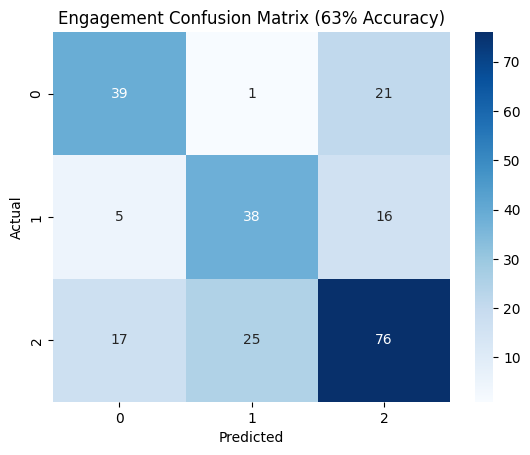

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib as plt
y_true = []
y_pred = []

for i in range(len(val_gen)):
    x, y = val_gen[i]
    preds = model.predict(x, verbose=0)
    y_true.extend(np.argmax(y, axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Engagement Confusion Matrix')
plt.show()

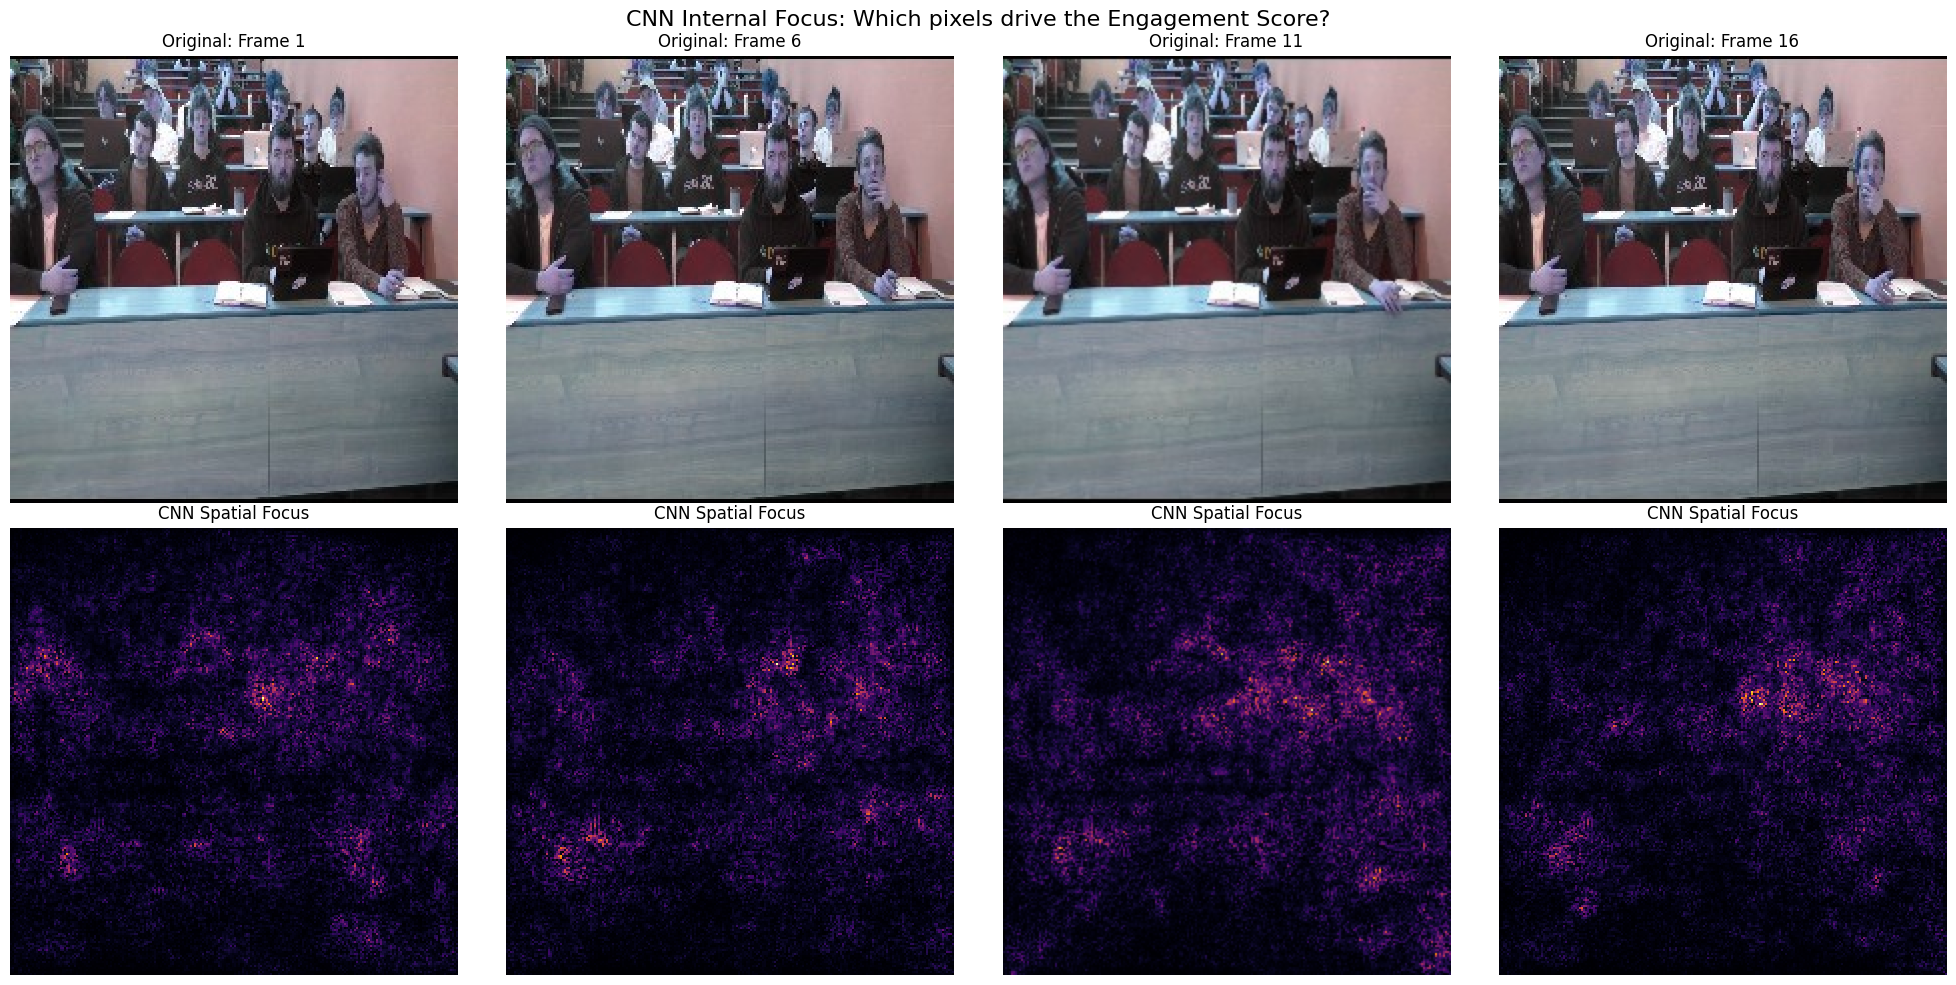

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

def generate_saliency_map(model, video_tensor, frame_idx):
    input_t = tf.convert_to_tensor(video_tensor, dtype=tf.float32)

    with tf.GradientTape() as tape:
        tape.watch(input_t)
        preds = model(input_t, training=False)
        target_class = tf.argmax(preds[0])
        loss = preds[:, target_class]

    grads = tape.gradient(loss, input_t)

    if grads is None:
        return np.zeros((224, 224)) 

    frame_grads = grads[0, frame_idx, :, :, :]

    focus_map = tf.reduce_max(tf.abs(frame_grads), axis=-1).numpy()

    focus_map = (focus_map - focus_map.min()) / (focus_map.max() - focus_map.min() + 1e-10)
    return focus_map

def plot_cnn_focus(model, video_tensor):
    indices = [0, 5, 10, 15]
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))

    for i, f_idx in enumerate(indices):
        saliency = generate_saliency_map(model, video_tensor, f_idx)

        axes[0, i].imshow(video_tensor[0, f_idx])
        axes[0, i].set_title(f"Original: Frame {f_idx+1}")
        axes[0, i].axis('off')

     
        axes[1, i].imshow(saliency, cmap='inferno')
        axes[1, i].set_title("CNN Spatial Focus")
        axes[1, i].axis('off')

    plt.suptitle("CNN Internal Focus: Which pixels drive the Engagement Score?", fontsize=16)
    plt.tight_layout()
    plt.show()

plot_cnn_focus(model, high_video_tensor)